In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/Users/amogh/Machine Learning Projects/LogisticRegression/iris.csv")
df = df.dropna()

In [5]:
xtrain = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
ytrain_labels = df['species'].values

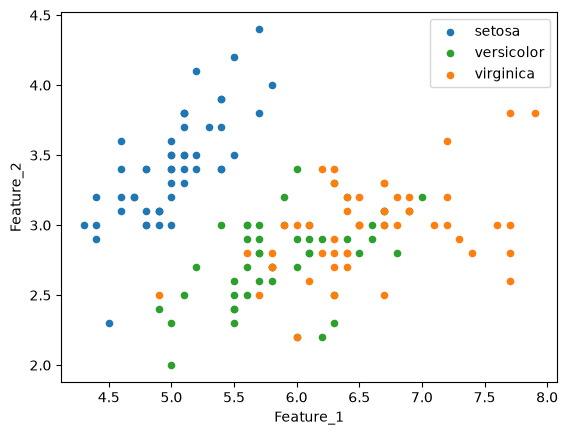

In [7]:
m, n = xtrain.shape
classes = pd.unique(ytrain_labels)
colors = ['tab:blue', 'tab:green', 'tab:orange']

for i, cls in enumerate(classes):
    plt.scatter(xtrain[ytrain_labels == cls, 0], xtrain[ytrain_labels == cls, 1],
                color=colors[i], label=str(cls), s=20)
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.legend()
plt.show()

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function(X, y, w, b):
    cost_sum = 0
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)
    return (1 / m) * cost_sum

In [9]:
def gradient_function(X, y, w, b):
    grad_w = np.zeros(n)
    grad_b = 0
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        grad_b += (g - y[i])
        for j in range(n):
            grad_w[j] += (g - y[i]) * X[i, j]
    grad_b = (1 / m) * grad_b
    grad_w = (1 / m) * grad_w
    return grad_b, grad_w


def gradient_descent(X, y, alpha, iterations):
    w = np.zeros(n)
    b = 0
    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)
        w = w - alpha * grad_w
        b = b - alpha * grad_b
        if i % 200 == 0:
            print(f"Iteration {i}: Cost {cost_function(X, y, w, b)}")
    return w, b

In [10]:
def predict_proba(X, w, b):
    preds = np.zeros(m)
    for i in range(m):
        z = np.dot(w, X[i]) + b
        preds[i] = sigmoid(z)
    return preds

In [11]:
learning_rate = 0.01
iterations = 1000

# ---- train one-vs-rest: one classifier per class ----
ovr_models = {}
for cls in classes:
    y_binary = (ytrain_labels == cls).astype(int)
    w, b = gradient_descent(xtrain, y_binary, learning_rate, iterations)
    ovr_models[cls] = (w, b)
    print(f"Finished training for class: {cls}")

# ---- multiclass prediction: pick class with highest probability ----
all_probs = np.zeros((m, len(classes)))
for idx, cls in enumerate(classes):
    w, b = ovr_models[cls]
    all_probs[:, idx] = predict_proba(xtrain, w, b)

predicted_indices = np.argmax(all_probs, axis=1)
predicted_labels = classes[predicted_indices]

accuracy = np.mean(predicted_labels == ytrain_labels) * 100
print(f"Training accuracy (multiclass OvR): {accuracy:.2f}%")


Iteration 0: Cost 0.6564300892794769
Iteration 200: Cost 0.21710305760248294
Iteration 400: Cost 0.12860557152417906
Iteration 600: Cost 0.09142780807437793
Iteration 800: Cost 0.07115887747799637
Finished training for class: setosa
Iteration 0: Cost 0.6791194059048741
Iteration 200: Cost 0.5983923958267074
Iteration 400: Cost 0.5865096804682184
Iteration 600: Cost 0.5807126108785944
Iteration 800: Cost 0.5764325080452829
Finished training for class: versicolor
Iteration 0: Cost 0.6851317431968332
Iteration 200: Cost 0.43202496567416104
Iteration 400: Cost 0.36355438767278175
Iteration 600: Cost 0.32805841524589885
Iteration 800: Cost 0.3043741677097338
Finished training for class: virginica
Training accuracy (multiclass OvR): 87.33%


In [12]:
# ---- plot decision boundaries (using only first 2 features for visualization) ----
# retrain 2-feature-only models just for plotting purposes
xtrain_2d = xtrain[:, :2]
m2, n2 = xtrain_2d.shape

def gradient_function_2d(X, y, w, b):
    grad_w = np.zeros(n2)
    grad_b = 0
    for i in range(m2):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        grad_b += (g - y[i])
        for j in range(n2):
            grad_w[j] += (g - y[i]) * X[i, j]
    grad_b = (1 / m2) * grad_b
    grad_w = (1 / m2) * grad_w
    return grad_b, grad_w

def gradient_descent_2d(X, y, alpha, iterations):
    w = np.zeros(n2)
    b = 0
    for i in range(iterations):
        grad_b, grad_w = gradient_function_2d(X, y, w, b)
        w = w - alpha * grad_w
        b = b - alpha * grad_b
    return w, b


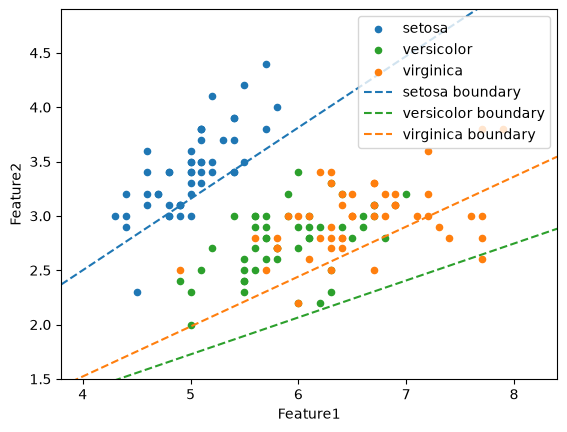

In [13]:
ovr_models_2d = {}
for cls in classes:
    y_binary = (ytrain_labels == cls).astype(int)
    w2, b2 = gradient_descent_2d(xtrain_2d, y_binary, learning_rate, iterations)
    ovr_models_2d[cls] = (w2, b2)

xmin, xmax = xtrain_2d[:, 0].min() - 0.5, xtrain_2d[:, 0].max() + 0.5
ymin, ymax = xtrain_2d[:, 1].min() - 0.5, xtrain_2d[:, 1].max() + 0.5
xd = np.array([xmin, xmax])

for i, cls in enumerate(classes):
    plt.scatter(xtrain_2d[ytrain_labels == cls, 0], xtrain_2d[ytrain_labels == cls, 1],
                color=colors[i], label=str(cls), s=20)

for i, cls in enumerate(classes):
    w2, b2 = ovr_models_2d[cls]
    mline = -w2[0] / w2[1]
    cline = -b2 / w2[1]
    yd = mline * xd + cline
    plt.plot(xd, yd, ls='--', color=colors[i], label=f'{cls} boundary')

plt.legend()
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()